In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import shap

plt.style.use('seaborn-v0_8')
%matplotlib inline

/home/dabiyyu/miniconda3/envs/ds-projects/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train churn rate:", y_train.mean().round(3))
print("y_test churn rate:", y_test.mean().round(3))

X_train: (5634, 31)
X_test: (1409, 31)
y_train churn rate: 0.265
y_test churn rate: 0.265


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }
    print(f"  ROC-AUC: {results[name]['roc_auc']:.4f}")

print("\nDone!")

Training Logistic Regression...
  ROC-AUC: 0.8491
Training Random Forest...
  ROC-AUC: 0.8392
Training Gradient Boosting...
  ROC-AUC: 0.8501

Done!


In [4]:
# Summary table
summary = pd.DataFrame({
    name: {
        'ROC-AUC': res['roc_auc'],
        'Precision (Churn)': res['report']['1']['precision'],
        'Recall (Churn)': res['report']['1']['recall'],
        'F1 (Churn)': res['report']['1']['f1-score'],
    }
    for name, res in results.items()
}).T.round(4)

print("Model Comparison:")
print(summary)

Model Comparison:
                     ROC-AUC  Precision (Churn)  Recall (Churn)  F1 (Churn)
Logistic Regression   0.8491             0.6456          0.5749      0.6082
Random Forest         0.8392             0.6526          0.5374      0.5894
Gradient Boosting     0.8501             0.6471          0.5294      0.5824


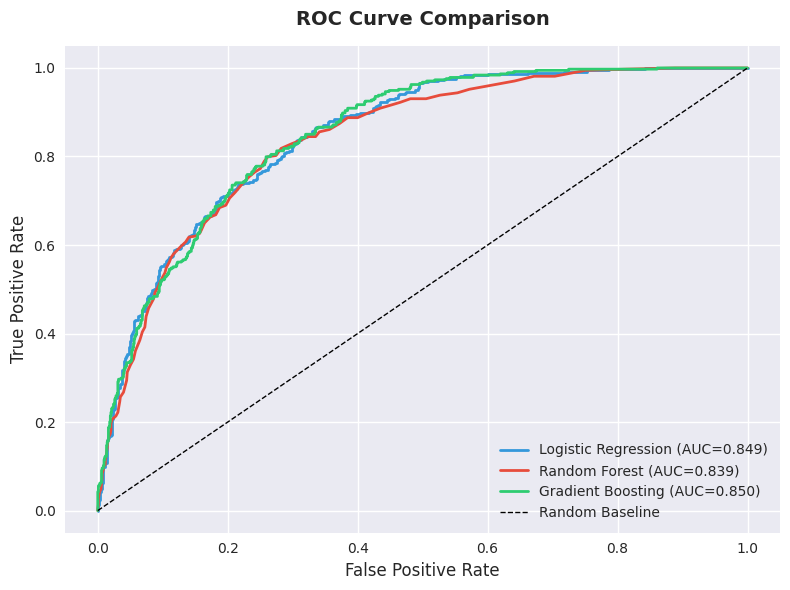

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})",
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right')
sns.despine()

plt.tight_layout()
plt.savefig('../reports/figures/08_roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model: Gradient Boosting
ROC-AUC: 0.8501


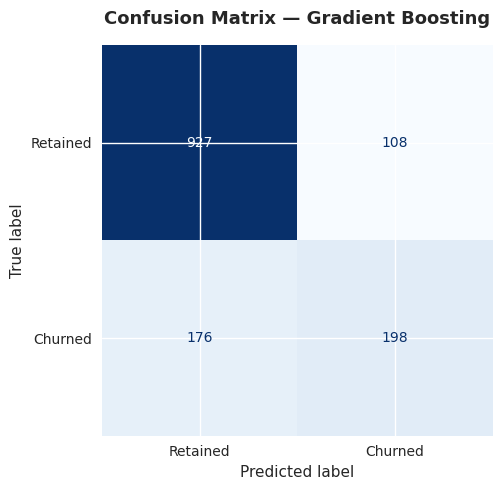


Business Interpretation:
  Correctly identified churners: 198 (True Positives)
  Missed churners: 176 (False Negatives)
  False alarms: 108 (False Positives)
  Correctly identified loyal customers: 927 (True Negatives)


In [6]:
# Pick best model by ROC-AUC
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']
best_pred = results[best_name]['y_pred']

print(f"Best model: {best_name}")
print(f"ROC-AUC: {results[best_name]['roc_auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/figures/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nBusiness Interpretation:")
print(f"  Correctly identified churners: {tp} (True Positives)")
print(f"  Missed churners: {fn} (False Negatives)")
print(f"  False alarms: {fp} (False Positives)")
print(f"  Correctly identified loyal customers: {tn} (True Negatives)")

Computing SHAP values (may take 1-2 minutes)...


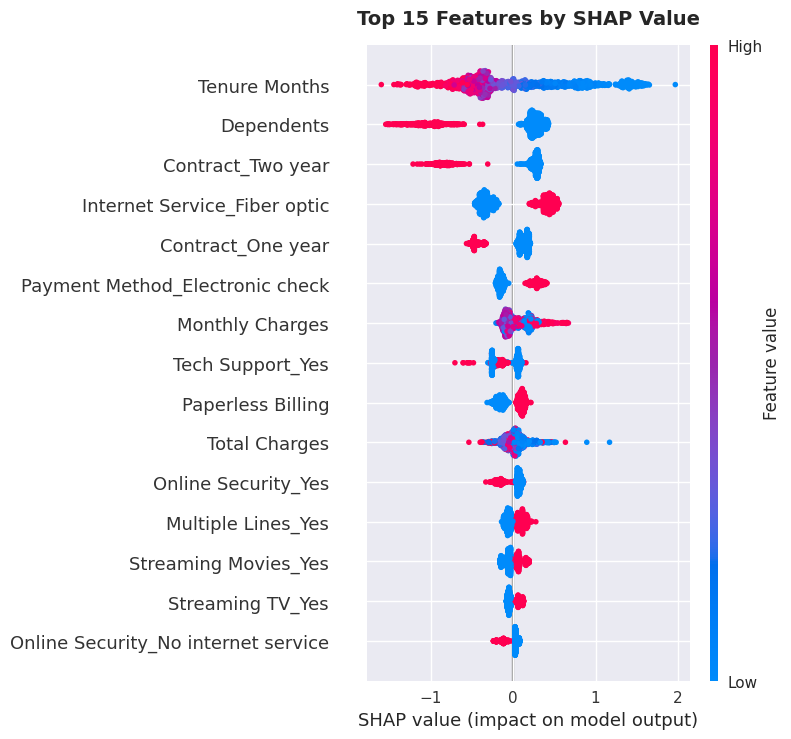

In [7]:
print("Computing SHAP values (may take 1-2 minutes)...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test,
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=False
)
plt.title('Top 15 Features by SHAP Value', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

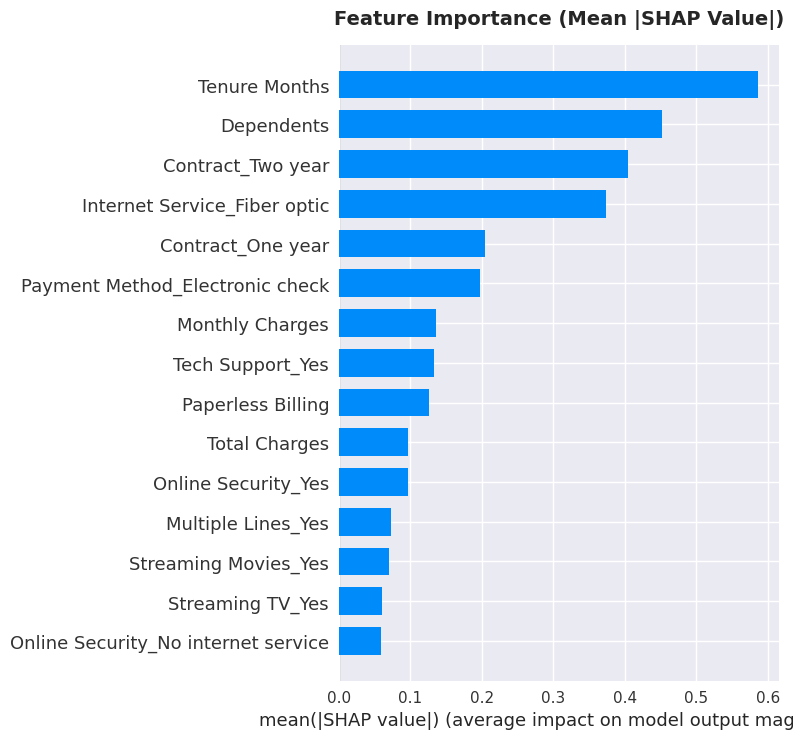

In [8]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for customer index: 1090
Predicted churn probability: 92.8%
Actual outcome: Churned


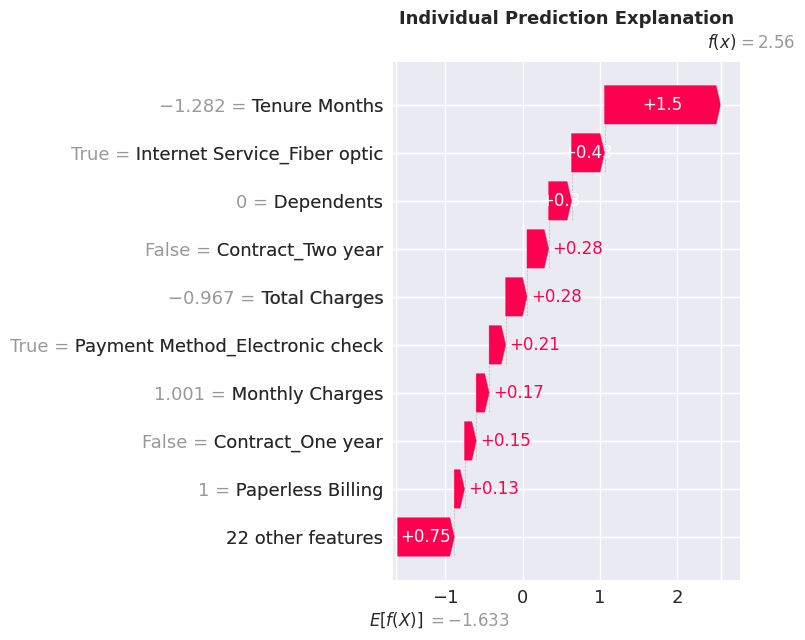

In [10]:
# Pick one high-risk customer to explain
high_risk_idx = results['Gradient Boosting']['y_prob'].argmax()

print(f"Explaining prediction for customer index: {high_risk_idx}")
print(f"Predicted churn probability: {results['Gradient Boosting']['y_prob'][high_risk_idx]:.1%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")

# Fix — create Explanation object directly from explainer
explanation = explainer(X_test)

shap.plots.waterfall(
    explanation[high_risk_idx],
    max_display=10,
    show=False
)
plt.title('Individual Prediction Explanation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/12_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved: {best_name}")
print(f"ROC-AUC: {results[best_name]['roc_auc']:.4f}")
print("Model saved to ../models/best_model.pkl")

Saved: Gradient Boosting
ROC-AUC: 0.8501
Model saved to ../models/best_model.pkl
